Successfully loaded shocksclean.dta
Total Rows: 1665
Cleaning Complete: Handled 'none' values and missing codes.


C:\Users\kitti\AppData\Local\Temp\ipykernel_7712\2529390113.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_2017_cleaned, x='shocks_Group', palette='plasma')


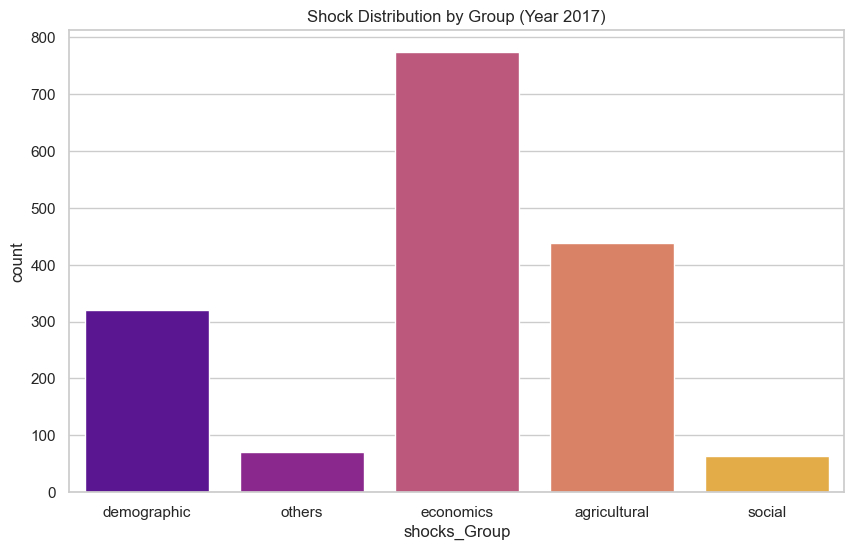

Process Complete! File saved as shocks_2017_final_processed.csv


In [4]:
# ==============================================================================
# 1. SETUP & LIBRARIES
# ==============================================================================
# Why: นำเข้าไลบรารีและตั้งค่าการแสดงผลเบื้องต้น
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==============================================================================
# 2. DATA LOADING (Solving Categorical Error)
# ==============================================================================
# Why: ใช้ convert_categoricals=False เพื่อป้องกัน Error "The repeated labels are..." 
# ซึ่งเกิดจากรหัสหมู่บ้าน/ตำบลใน Stata มีชื่อซ้ำกัน
def load_2017_shocks(file_path):
    # โหลดไฟล์โดยไม่แปลงเป็น Category อัตโนมัติ เพื่อข้าม Error
    df = pd.read_stata(file_path, convert_categoricals=False)
    print(f"Successfully loaded {file_path}")
    print(f"Total Rows: {len(df)}")
    return df

# แนะนำให้ใช้ไฟล์ 'shocksclean.dta' เนื่องจากเป็นไฟล์ที่ผ่านการตรวจสอบเบื้องต้นแล้ว
df_2017_raw = load_2017_shocks('shocksclean.dta')

# ==============================================================================
# 3. DATA CLEANING (Handling 'none' and -9, -99)
# ==============================================================================
# Why: จัดการค่าที่ทำให้การคำนวณผิดพลาด
def clean_2017_logic(df):
    # 1. จัดการค่าว่างมาตรฐาน Stata (-9, -99)
    df = df.replace([-9, -99, -9.0, -99.0], np.nan)
    
    # 2. จัดการคอลัมน์มูลค่าความเสียหาย (มักจะเป็น _x31005a, _x31005b, _x31006a)
    # แปลง 'none' ให้เป็น 0 และทำให้เป็นตัวเลข (Float)
    loss_cols = ['_x31005a', '_x31005b', '_x31006a']
    for col in loss_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('none', '0', case=False).str.strip()
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
            
    print("Cleaning Complete: Handled 'none' values and missing codes.")
    return df

df_2017_cleaned = clean_2017_logic(df_2017_raw)

# ==============================================================================
# 4. SHOCK TRANSFORMATION (Manual Mapping for Panel Consistency)
# ==============================================================================
# Why: เนื่องจากเราปิด convert_categoricals เราจึงต้อง Map ชื่อกลุ่มเองให้ตรงกับปี 2022

# Mapping ตามรหัสใน Questionnaire 2017
shock_labels_2017 = {
    1: 'Illness of household member', 2: 'Death of household member',
    3: 'Household member left the household', 5: 'Had to spend money because of ceremony',
    6: 'House damage', 8: 'Conflict with neigbours in the village',
    10: 'Flooding of agricultural land', 11: 'Drought',
    16: 'Landslides, erosion', 18: 'Collapse of business',
    21: '21 - Strong decrease of prices for output',
    22: '22 - Strong increase of prices for input',
    24: 'Accident', 46: 'Being cheated at work/business',
    55: 'Storm', 62: 'Job loss', 63: 'Pests and livestock diseases',
    70: 'Theft/Robbery/Vandalism', 71: 'Theft/Robbery/Vandalism',
    72: 'Theft/Robbery/Vandalism', 73: 'Theft/Robbery/Vandalism',
    74: 'Theft/Robbery/Vandalism', 75: 'Theft/Robbery/Vandalism',
    76: 'Theft/Robbery/Vandalism', 77: 'Flooding on the house/homestead',
    90: 'Other, specify'
}

def categorize_shock_2017(desc):
    """จัดกลุ่มตาม Research Logic เพื่อให้เทียบเคียงกับปี 2022 ได้"""
    if desc in ['Drought', 'Flooding of agricultural land', 'Pests and livestock diseases', 'Storm', 'Landslides, erosion']:
        return "agricultural"
    elif desc in ['Illness of household member', 'Death of household member', 'Accident', 'Household member left the household']:
        return "demographic"
    elif desc in ['House damage', 'Job loss', '21 - Strong decrease of prices for output', 
                  '22 - Strong increase of prices for input', 'Had to spend money because of ceremony', 'Collapse of business']:
        return "economics"
    elif desc in ['Conflict with neigbours in the village', 'Theft/Robbery/Vandalism']:
        return "social"
    return "others"

# สร้างตัวแปรใหม่
df_2017_cleaned['shock_description'] = df_2017_cleaned['_x31002'].map(shock_labels_2017)
df_2017_cleaned['shocks_Group'] = df_2017_cleaned['shock_description'].apply(categorize_shock_2017)

# เพิ่มตัวระบุปีสำหรับทำ Panel Data
df_2017_cleaned['survey_year'] = 2017

# ==============================================================================
# 5. VISUALIZATION
# ==============================================================================
plt.figure(figsize=(10, 6))
sns.countplot(data=df_2017_cleaned, x='shocks_Group', palette='plasma')
plt.title('Shock Distribution by Group (Year 2017)')
plt.show()

# ==============================================================================
# 6. EXPORT
# ==============================================================================
# เซฟไฟล์เป็น CSV เพื่อใช้ในการ Append กับปีอื่นๆ
output_name = 'shocks_2017_final_processed.csv'
df_2017_cleaned.to_csv(output_name, index=False)
print(f"Process Complete! File saved as {output_name}")